# Machine Learning / Deep Learning on an AI-Ready Satellite **Data Cube**
### A friendly, runnable example (no downloads, no credentials needed)

<a href="https://colab.research.google.com/github/buckai-observatory/geoai-datacubes/blob/main/notebooks/02_minicube_ml_quickstart.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

Welcome! This notebook walks you, step by step, through doing **machine learning / deep learning (ML/DL) on
satellite imagery** using a *data cube* produced by this repository's pipeline
(`modules/sentinel_pipeline`). It is written **for beginners** -- if you have ever
opened a Jupyter notebook and run `pip install`, you can follow along.

By the end you will have:

1. **Opened** a real satellite data cube (a small sample is committed in this repo).
2. **Visualized** the imagery and computed **NDVI** (a classic "how green is this pixel?" index).
3. **Trained a tiny deep-learning (DL) model** (a mini U-Net in PyTorch) **end-to-end on your CPU**
 in well under a couple of minutes, to predict a *vegetation mask*.
4. **Optionally** clustered pixels with **KMeans (ML)** for a label-free first cut.
5. Learned **how to point this notebook at your *own* cube** and where to go next.

---

### What is a "data cube"?

When you run this repo's pipeline (`python modules/sentinel_pipeline/main.py`) it:

- downloads **Sentinel-2** satellite imagery for a region and date range,
- cuts the big image into many small **256 x 256 tiles**, and
- saves those tiles into a **Zarr group** (an array storage format that works great for ML/DL).

Inside that Zarr group, every tile is stored as a dataset named `tile_00000`,
`tile_00001`, ... Each tile is a small 3-D array with shape **`(C, H, W)`** =
`(channels, height, width)`, stored as 32-bit floats. "Channels" here are the
**spectral bands** the satellite recorded (e.g. red light, near-infrared light).
A sibling file `metadata.json` records where each tile came from.

You can think of the whole thing as a **stack of image layers** -- that stack is the
"cube". (Created by `modules/sentinel_pipeline/export_zarr.py`.)

---

### Prerequisites

Install the dependencies from the repo root:

```bash
pip install -r requirements.txt
```

The only libraries this notebook actually needs are: **zarr**, **numpy**,
**matplotlib**, and **torch** (plus optional **scikit-learn** for the KMeans bonus cell).
Everything runs on a laptop CPU -- no GPU required.

> **Running on Google Colab?** This notebook is self-bootstrapping -- open it
> via the badge above and just run the cells. The next code cell detects
> Colab, shallow-clones the repo into `/content/geoai-datacubes`, installs
> the handful of packages not in Colab's default image, and chdir's so the
> `find_repo_root` helper picks up the cloned tree. On a local Jupyter run
> that same cell is a quick no-op.

In [1]:
# --- Colab / local bootstrap ---
# On Colab, this cell clones the repo (so the bundled mini Zarr cube is
# available offline) and installs the few packages not in Colab's default
# runtime. On a local Jupyter run it is a no-op that just confirms the
# repo layout. Re-running it is safe.

import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected -- bootstrapping repo + dependencies")
    REPO_DIR = Path("/content/geoai-datacubes")
    if not REPO_DIR.exists():
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/buckai-observatory/geoai-datacubes.git",
            str(REPO_DIR),
        ])
    else:
        print(f"repo already cloned at {REPO_DIR}")

    # Colab pre-installs numpy / matplotlib / scikit-learn / scikit-image /
    # torch. The minicube Zarr-v3 store needs a recent zarr; install only
    # what's actually missing.
    missing = []
    for pkg, importname, minver in [("zarr", "zarr", "3")]:
        try:
            mod = __import__(importname)
            if int(getattr(mod, "__version__", "0").split(".")[0]) < int(minver):
                missing.append(pkg)
        except ImportError:
            missing.append(pkg)
    if missing:
        print(f"pip install -q {' '.join(missing)}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    # Land in the notebooks/ folder so the find_repo_root helper below
    # picks up the cloned repo cleanly.
    os.chdir(REPO_DIR / "notebooks")
    print(f"cwd = {os.getcwd()}")
else:
    print("Local environment -- using existing checkout")

Local environment -- using existing checkout


Let's import the libraries we'll use. If any import fails, run
`pip install -r requirements.txt` from the repo root and restart the kernel.

In [2]:
import os
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make plots show up inline in the notebook.
%matplotlib inline

# Reproducibility: fix random seeds so results are the same every run.
np.random.seed(0)

print("numpy   :", np.__version__)
import matplotlib
print("matplotlib:", matplotlib.__version__)

numpy   : 1.26.4
matplotlib: 3.9.4


## 2. Load the data cube

First we need to **find** the sample cube that ships with this repo. The cell below
resolves paths **relative to the repository root**, so this notebook works whether you
launch Jupyter from the repo root *or* from inside the `notebooks/` folder.

We look for a committed sample cube under
`modules/sentinel_pipeline/data/.../tiles_v2/train.zarr`. If for some reason none is
found, the notebook will fall back to a clearly-labelled **synthetic** cube so it still
runs (but the real sample should be present).

In [3]:
def find_repo_root(start: Path) -> Path:
    '''Walk upward from `start` until we find the repo root.

    We recognise the root by the presence of the `modules/sentinel_pipeline` folder
    (and/or a `.git` directory). This lets the notebook run from anywhere.
    '''
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "modules" / "sentinel_pipeline").is_dir():
            return candidate
        if (candidate / ".git").exists() and (candidate / "requirements.txt").exists():
            return candidate
    # Fallback: assume the notebook lives in <repo>/notebooks/
    return start.resolve().parent

# In a .ipynb there is no __file__, so start from the current working directory.
REPO_ROOT = find_repo_root(Path.cwd())
print("Repo root resolved to:", REPO_ROOT)

# Candidate sample cubes, in order of preference. These ship in the repo.
CANDIDATE_CUBES = [
    "notebooks/sample_data/mini_cube",   # small bundled sample (ships in repo)
    "modules/sentinel_pipeline/data/853de8cdfef01afe5935ff340561ca1e/tiles_v2/train.zarr",
    "modules/sentinel_pipeline/data/853de8cdfef01afe5935ff340561ca1e/train.zarr",
]

CUBE_PATH = None
for rel in CANDIDATE_CUBES:
    full = REPO_ROOT / rel
    if full.exists():
        CUBE_PATH = full
        break

if CUBE_PATH is None:
    print("No committed cube found - we'll synthesize one later (clearly labelled).")
else:
    print("Using data cube:", CUBE_PATH)

Repo root resolved to: /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes
Using data cube: /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/sample_data/mini_cube


Now we **open the Zarr group** and load the tiles into a single NumPy array.

A few practical notes:

- Tiles are stored as sub-groups named `tile_00000`, `tile_00001`, ... We sort
  the names so the order is deterministic.
- To keep this demo fast, we only load a **handful of tiles** (`MAX_TILES`).
  The full cube has hundreds -- feel free to raise this number on a faster
  machine.
- We also read the sibling **`metadata.json`** so you can see what information
  the pipeline records about each tile.
- The loader tries `zarr.open_group` first; if your local `zarr` is too old to
  read this cube's format (it ships as Zarr v3), it falls back to a tiny raw
  chunk reader built on `numcodecs`. Either way the rest of the notebook
  doesn't care -- you end up with a `(N, C, H, W)` float32 array.

In [4]:
MAX_TILES = 24          # how many tiles to load for this demo (keep small = fast)
USE_SYNTHETIC = False   # set automatically below if no real cube is found

tiles = []              # will become a list of (C, H, W) arrays
tile_names = []
metadata = None


def _list_tile_dirs(cube_path):
    """Return sorted tile names from the cube root (works for v2 + v3)."""
    return sorted(
        p.name for p in Path(cube_path).iterdir()
        if p.is_dir() and p.name.startswith("tile_")
    )


def _load_tile_via_zarr(cube_path, name):
    """Fast path: use zarr if it can open the store."""
    import zarr
    group = zarr.open_group(str(cube_path), mode="r")
    return np.asarray(group[name][:], dtype=np.float32)


def _load_tile_raw_v3(cube_path, name):
    """Fallback for envs whose zarr can't read Zarr-v3 stores.

    Reads the tile's `zarr.json` to discover shape / chunk_shape / codecs,
    then decodes each chunk file under `<tile>/c/<i>/<j>/<k>` directly with
    `numcodecs`. Only supports the simple bytes+zstd codec pipeline that
    `export_zarr.py` writes -- which is exactly what the bundled mini_cube
    uses. This keeps the notebook runnable without forcing a `zarr>=3`
    install on legacy envs.
    """
    import itertools
    from numcodecs import Zstd

    tile_dir = Path(cube_path) / name
    spec = json.loads((tile_dir / "zarr.json").read_text())
    shape = tuple(spec["shape"])
    chunk = tuple(spec["chunk_grid"]["configuration"]["chunk_shape"])
    dtype = np.dtype(spec["data_type"])

    # Build decoder chain from the codec list. We only need to support
    # `bytes` (a no-op endianness marker) and `zstd` (compression) here.
    decoders = []
    for codec in spec.get("codecs", []):
        if codec["name"] == "zstd":
            decoders.append(Zstd())
        elif codec["name"] in ("bytes", "endian"):
            pass  # bytes codec is just a dtype marker; no transform.
        else:
            raise RuntimeError(f"Unsupported zarr-v3 codec {codec['name']!r}")

    n_chunks = [(s + c - 1) // c for s, c in zip(shape, chunk)]
    out = np.zeros(shape, dtype=dtype)
    for idx in itertools.product(*[range(n) for n in n_chunks]):
        key = "/".join(["c", *map(str, idx)])
        raw = (tile_dir / key).read_bytes()
        buf = raw
        for dec in reversed(decoders):
            buf = dec.decode(buf)
        chunk_arr = np.frombuffer(buf, dtype=dtype).reshape(chunk)
        slices = tuple(
            slice(i * c, min((i + 1) * c, s)) for i, c, s in zip(idx, chunk, shape)
        )
        sub = tuple(slice(0, sl.stop - sl.start) for sl in slices)
        out[slices] = chunk_arr[sub]
    return out.astype(np.float32, copy=False)


def load_tile(cube_path, name):
    """Try the fast zarr path first; fall back to a raw chunk reader."""
    try:
        return _load_tile_via_zarr(cube_path, name)
    except Exception:
        return _load_tile_raw_v3(cube_path, name)


if CUBE_PATH is not None:
    tile_names = _list_tile_dirs(CUBE_PATH)
    print(f"Total tiles in this cube: {len(tile_names)}")
    print("First few tile names:", tile_names[:5])

    for name in tile_names[:MAX_TILES]:
        tiles.append(load_tile(CUBE_PATH, name))

    # Read metadata.json (a plain JSON file sitting next to the tiles).
    meta_path = CUBE_PATH / "metadata.json"
    if meta_path.exists():
        with open(meta_path) as f:
            metadata = json.load(f)

if not tiles:
    # ---- Fallback: synthesize a tiny, clearly-labelled cube ----
    USE_SYNTHETIC = True
    print("\n*** USING SYNTHETIC DATA (no real cube found) ***")
    rng = np.random.default_rng(0)
    for i in range(MAX_TILES):
        # 2 channels (red, NIR) of smooth-ish noise in a 0-255 range.
        base = rng.random((256, 256)).astype(np.float32)
        red = (base * 120 + 40)
        nir = (base * 60 + 120)  # NIR generally higher over "vegetation"
        tiles.append(np.stack([red, nir], axis=0))
    tile_names = [f"synthetic_{i:05d}" for i in range(MAX_TILES)]

# Stack into one big array: shape (N, C, H, W)
cube = np.stack(tiles, axis=0)

N, C, H, W = cube.shape
print("\nLoaded cube array:")
print("  number of tiles   (N):", N)
print("  channels per tile (C):", C)
print("  tile height       (H):", H)
print("  tile width        (W):", W)
print("  dtype:", cube.dtype)
print("  value range: min=%.1f  max=%.1f" % (cube.min(), cube.max()))

Total tiles in this cube: 16
First few tile names: ['tile_00000', 'tile_00001', 'tile_00002', 'tile_00003', 'tile_00004']

Loaded cube array:
  number of tiles   (N): 16
  channels per tile (C): 2
  tile height       (H): 256
  tile width        (W): 256
  dtype: float32
  value range: min=0.0  max=255.0


Let's peek at the **metadata**. The pipeline stores one record per tile (filename, the
pixel offset it was cropped from, the train/val/test split it was assigned, any
augmentation applied, etc.).

In [5]:
if metadata:
    print("metadata.json has", len(metadata), "records.")
    print("Fields recorded per tile:", list(metadata[0].keys()))
    print("\nExample record:")
    for k, v in metadata[0].items():
        print(f"{k}: {v}")
else:
    print("No metadata.json available (this is fine - e.g. synthetic data).")

metadata.json has 32 records.
Fields recorded per tile: ['filename', 'x_offset', 'y_offset', 'width', 'height', 'augmentation', 'split', 'tile_name', 'path']

Example record:
filename: tile_00003_noise.tif
x_offset: 675
y_offset: 0
width: 256
height: 256
augmentation: noise
split: train
tile_name: tile_00015
path: train/tile_00003_noise.tif


## 3. Visualize the imagery and compute NDVI

### Which band is which?

This repo's pipeline requests Sentinel-2 bands in this order (see
`modules/sentinel_pipeline/main.py`):

| Channel index | Band | Meaning |
|:---:|:---:|---|
| 0 | **B04** | **Red** light |
| 1 | **B08** | **Near-infrared (NIR)** |

(The full pipeline can also tack on SCL/AOT/WVP quality bands, but the committed
sample cube contains just the two we need.) The cell below is defensive: it figures out
which channels to treat as Red and NIR and explains its assumption, so it won't crash if
your cube has a different number of channels.

In [6]:
# Decide which channel indices are Red and NIR.
# Convention from main.py: channel 0 = Red (B04), channel 1 = NIR (B08).
if C >= 2:
    RED_IDX, NIR_IDX = 0, 1
    print(f"Assuming channel {RED_IDX} = Red (B04) and channel {NIR_IDX} = NIR (B08).")
else:
    # Only one band: we can't do NDVI, so reuse it for both (NDVI will be ~0).
    RED_IDX = NIR_IDX = 0
    print("Only one channel present - NDVI will be trivial. Visuals still work.")


def to_display(img2d):
    '''Scale a single 2-D band to [0,1] just for nicer display.'''
    lo, hi = np.percentile(img2d, [2, 98])  # robust contrast stretch
    if hi <= lo:
        hi = lo + 1e-6
    return np.clip((img2d - lo) / (hi - lo), 0, 1)


def compute_ndvi(tile):
    '''NDVI = (NIR - Red) / (NIR + Red). Ranges from -1 to +1; high = green vegetation.'''
    red = tile[RED_IDX].astype(np.float32)
    nir = tile[NIR_IDX].astype(np.float32)
    return (nir - red) / (nir + red + 1e-6)

Assuming channel 0 = Red (B04) and channel 1 = NIR (B08).


Now we **display a few tiles**. For each tile we show:

- the **Red** band (grayscale),
- the **NIR** band (grayscale), and
- the **NDVI** map (red = bare/built-up, green = vegetation).

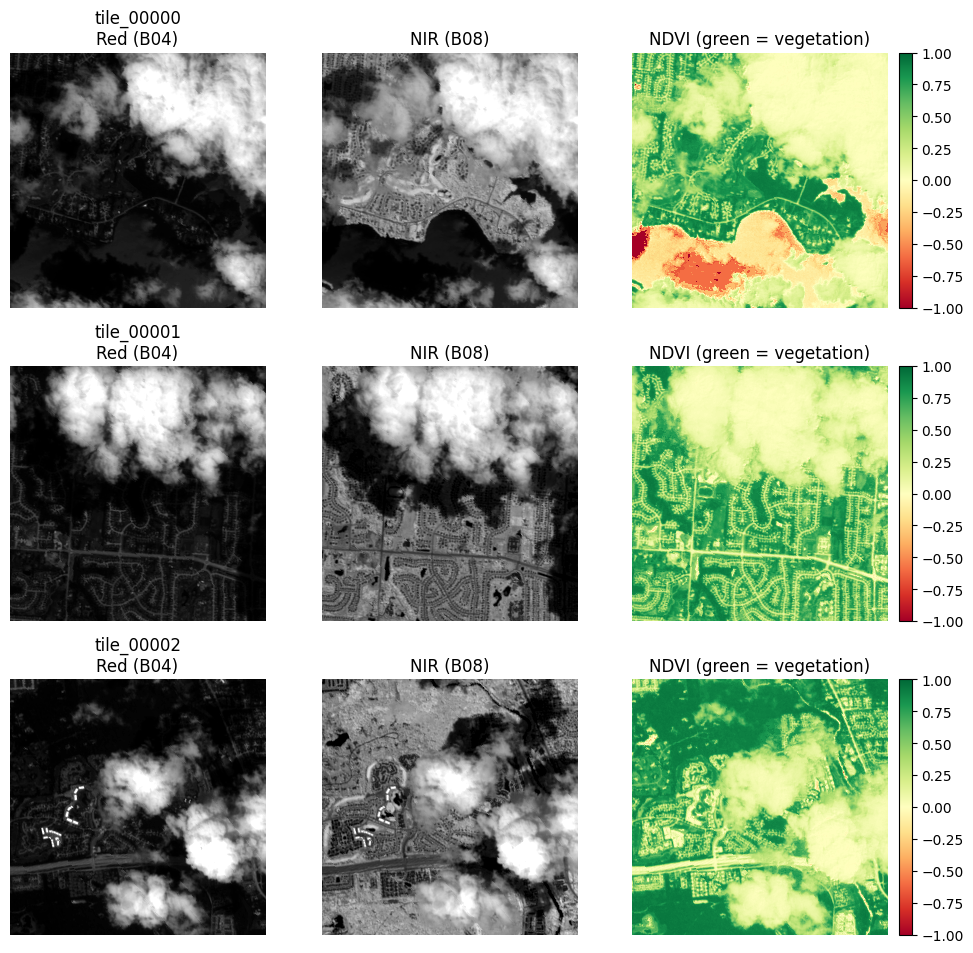

In [7]:
n_show = min(3, N)
fig, axes = plt.subplots(n_show, 3, figsize=(10, 3.2 * n_show))
if n_show == 1:
    axes = axes[None, :]

for r in range(n_show):
    tile = cube[r]
    ndvi = compute_ndvi(tile)

    axes[r, 0].imshow(to_display(tile[RED_IDX]), cmap="gray")
    axes[r, 0].set_title(f"{tile_names[r]}\nRed (B04)")

    axes[r, 1].imshow(to_display(tile[NIR_IDX]), cmap="gray")
    axes[r, 1].set_title("NIR (B08)")

    im = axes[r, 2].imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
    axes[r, 2].set_title("NDVI (green = vegetation)")
    fig.colorbar(im, ax=axes[r, 2], fraction=0.046, pad=0.04)

    for c in range(3):
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()

## 4. A real (but tiny) deep-learning demo: predicting a vegetation mask

Here is the fun part. We'll train a **small convolutional neural network** (a "mini
U-Net" -- a concrete DL model) **end-to-end on your CPU** in under a couple of minutes.

### The trick: pseudo-labels (no manual labelling required!)

Real ML/DL usually needs **labels** (someone hand-marking "this pixel is forest, that one is
road"). We don't have those here, so we **make our own labels automatically** from NDVI:

> **vegetation mask** = 1 where `NDVI > 0.3`, else 0

This is called a **pseudo-label** (a self-supervised-style trick). We then train the CNN
to predict that mask **from the raw bands**. The model never sees NDVI directly -- it has
to *learn* the relationship between the raw Red/NIR pixels and "is this vegetation?".

> **Why is this useful / not circular?** For this demo it's mostly illustrative: it proves
> the full training loop works and that a CNN can learn a spatial mapping. In a real
> project you would **swap the pseudo-label for your own real labels** (crop type, burn
> scar, water, building footprints, ...) and keep everything else the same. We show
> exactly where to do that at the end.

In [8]:
import torch
import torch.nn as nn

torch.manual_seed(0)
DEVICE = "cpu"   # this demo is intentionally CPU-friendly
print("Using torch", torch.__version__, "on", DEVICE)

Using torch 2.8.0 on cpu


### Build the training data

We turn our loaded tiles into:

- **inputs** `X`: the raw bands, lightly normalized to roughly `[0, 1]`.
- **targets** `y`: the NDVI-threshold vegetation mask (0 or 1 per pixel).

Then we split into a small **train** and **validation** set.

In [9]:
NDVI_VEG_THRESHOLD = 0.3   # NDVI above this is treated as "vegetation"

# Normalize inputs. Sentinel reflectance here is stored on a 0-255-ish scale,
# so dividing by 255 gives a friendly ~[0,1] range. (Robust to other scales:
# if values are already small, this just makes them smaller, which is fine.)
scale = max(cube.max(), 1.0)
X = (cube / scale).astype(np.float32)                       # (N, C, H, W)

# Build pseudo-labels from NDVI for every tile.
y = np.stack([(compute_ndvi(cube[i]) > NDVI_VEG_THRESHOLD)
              for i in range(N)], axis=0).astype(np.float32)  # (N, H, W)
y = y[:, None, :, :]                                         # (N, 1, H, W)

veg_fraction = y.mean()
print(f"Average vegetation fraction across tiles: {veg_fraction*100:.1f}%")

# Shuffle tiles, then split into train / validation. Shuffling makes the two
# sets representative of each other (otherwise we might validate on tiles that
# look nothing like the ones we trained on).
perm = np.random.permutation(N)
X, y = X[perm], y[perm]

n_val = max(1, N // 5)
X_train, y_train = X[:-n_val], y[:-n_val]
X_val,   y_val   = X[-n_val:], y[-n_val:]
print(f"Train tiles: {len(X_train)} | Val tiles: {len(X_val)}")

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_val_t   = torch.from_numpy(X_val)
y_val_t   = torch.from_numpy(y_val)

Average vegetation fraction across tiles: 57.0%
Train tiles: 13 | Val tiles: 3


### Define a tiny U-Net

A **U-Net** is the classic architecture for image segmentation (labelling every pixel).
Ours is deliberately minimal: one down-sampling step, one up-sampling step, very few
filters. It takes `C` input channels and outputs **1 channel** (the predicted
vegetation probability per pixel).

In [10]:
class TinyUNet(nn.Module):
    '''A minimal U-Net for per-pixel binary segmentation.'''

    def __init__(self, in_channels, base=8):
        super().__init__()

        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1), nn.ReLU(inplace=True),
            )

        self.enc1 = block(in_channels, base)        # full resolution
        self.pool = nn.MaxPool2d(2)
        self.enc2 = block(base, base * 2)           # half resolution (bottleneck)
        self.up = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = block(base * 2, base)           # back to full resolution
        self.head = nn.Conv2d(base, 1, 1)           # 1x1 conv -> 1 output channel

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        d1 = self.up(e2)
        d1 = torch.cat([d1, e1], dim=1)             # skip connection
        d1 = self.dec1(d1)
        return self.head(d1)                        # logits (no sigmoid yet)


model = TinyUNet(in_channels=C, base=8).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"TinyUNet created with {n_params:,} parameters (tiny on purpose).")

TinyUNet created with 6,497 parameters (tiny on purpose).


### Train it!

We use a small batch size, a handful of epochs, and `BCEWithLogitsLoss` (the standard
loss for binary per-pixel masks). Watch the **loss go down** — that means the model is
learning. This loop runs in well under a couple of minutes on a CPU.

In [11]:
EPOCHS = 5
BATCH_SIZE = 4
LR = 2e-3

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def iterate_batches(X_t, y_t, bs):
    indices = torch.randperm(len(X_t))
    for i in range(0, len(X_t), bs):
        j = indices[i:i + bs]
        yield X_t[j], y_t[j]


for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    n_batches = 0
    for xb, yb in iterate_batches(X_train_t, y_train_t, BATCH_SIZE):
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item()
        n_batches += 1
    train_loss = running / max(n_batches, 1)

    # Validation loss + pixel accuracy.
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
        val_pred = (torch.sigmoid(val_logits) > 0.5).float()
        val_acc = (val_pred == y_val_t).float().mean().item()

    print(f"Epoch {epoch}/{EPOCHS} | train loss {train_loss:.4f}"
          f"| val loss {val_loss:.4f} | val pixel-acc {val_acc*100:.1f}%")

print("\nDone training.")

Epoch 1/5 | train loss 0.7285| val loss 0.7426 | val pixel-acc 37.0%


Epoch 2/5 | train loss 0.7216| val loss 0.7190 | val pixel-acc 37.0%


Epoch 3/5 | train loss 0.7014| val loss 0.6895 | val pixel-acc 67.1%


Epoch 4/5 | train loss 0.6945| val loss 0.6568 | val pixel-acc 62.9%


Epoch 5/5 | train loss 0.6911| val loss 0.6427 | val pixel-acc 63.2%

Done training.


### Look at the predictions

For one validation tile we show, side by side:

1. the input (NIR band), 2. the **pseudo-label** mask (our NDVI-threshold target), and
3. the **model's prediction**. If training worked, panels 2 and 3 should look similar.

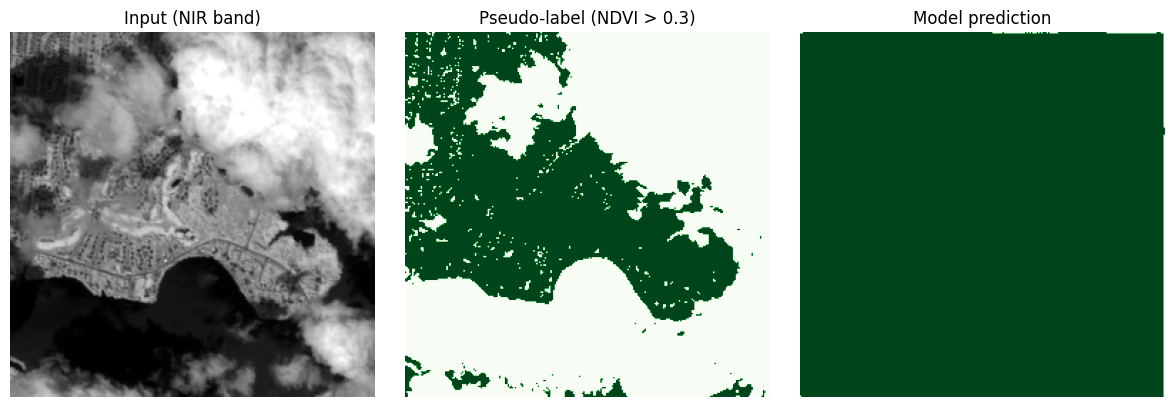

Pixel agreement on this tile: 38.9%


In [12]:
model.eval()
with torch.no_grad():
    sample = X_val_t[:1]
    pred_prob = torch.sigmoid(model(sample))[0, 0].numpy()
pred_mask = (pred_prob > 0.5).astype(np.float32)

true_mask = y_val_t[0, 0].numpy()
nir_view = to_display(X_val[0, NIR_IDX])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(nir_view, cmap="gray");          axes[0].set_title("Input (NIR band)")
axes[1].imshow(true_mask, cmap="Greens");       axes[1].set_title("Pseudo-label (NDVI > %.1f)" % NDVI_VEG_THRESHOLD)
axes[2].imshow(pred_mask, cmap="Greens");       axes[2].set_title("Model prediction")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

agreement = (pred_mask == true_mask).mean()
print(f"Pixel agreement on this tile: {agreement*100:.1f}%")

That's a complete deep-learning pipeline: **data -> labels -> model -> training ->
prediction**. Everything is intentionally tiny so it runs fast; on real projects you'd
use more tiles, more epochs, a bigger model, and (most importantly) **real labels**.

---

### Bonus (optional): unsupervised land-cover with KMeans (ML)

An even simpler approach needs **no neural network and no labels at all**: cluster the
pixels by their band values with **KMeans (a classical ML method)**. Each cluster
becomes a candidate land-cover class. This is a quick way to get a first "segmentation"
of a scene. (Requires `scikit-learn`; skip it if you don't have it installed.)

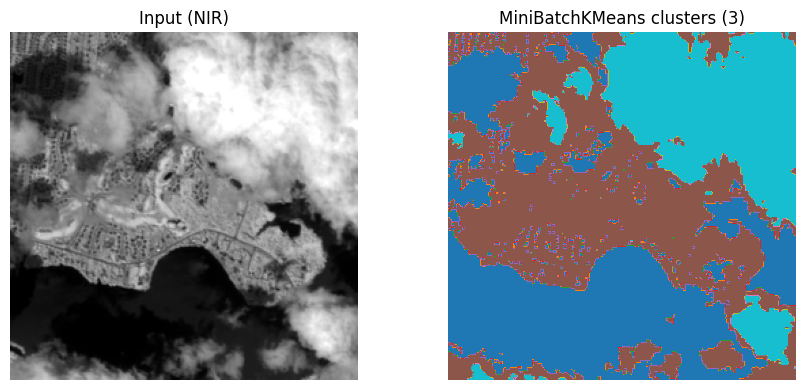

In [13]:
try:
    # threadpoolctl ships with scikit-learn; we use it to cap the BLAS /
    # OpenMP thread count for this cell. Without that cap, on a few stacks
    # (notably macOS + Anaconda where NumPy/PyTorch and scikit-learn each
    # load their own libomp) KMeans's threadpool warmup can deadlock for
    # tens of minutes. Capping threads makes this bonus cell predictable.
    try:
        from threadpoolctl import threadpool_limits
    except ImportError:  # pragma: no cover -- threadpoolctl is an sklearn dep
        from contextlib import contextmanager

        @contextmanager
        def threadpool_limits(*_args, **_kwargs):
            yield

    from sklearn.cluster import MiniBatchKMeans

    tile = cube[0]                                   # (C, H, W)
    pixels = tile.reshape(C, -1).T                   # (H*W, C) - one row per pixel

    with threadpool_limits(limits=1):
        # MiniBatchKMeans is fast on a single tile and avoids the heavy
        # multi-init / multi-threaded path of full KMeans.
        km = MiniBatchKMeans(
            n_clusters=3, n_init=3, batch_size=4096,
            random_state=0, max_iter=100,
        ).fit(pixels)
    seg = km.labels_.reshape(H, W)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(to_display(tile[NIR_IDX]), cmap="gray"); axes[0].set_title("Input (NIR)")
    axes[1].imshow(seg, cmap="tab10");                      axes[1].set_title("MiniBatchKMeans clusters (3)")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("scikit-learn not installed - skipping the optional KMeans demo.")
except Exception as e:
    # KMeans is just a bonus; never let it break the notebook.
    print("Skipping optional KMeans demo (it raised:", type(e).__name__, "-", e, ")")

## 5. Next steps: use *your own* data cube

### Point this notebook at your cube

When you run the pipeline yourself:

```bash
cd modules/sentinel_pipeline
python main.py # downloads + tiles imagery
python export_zarr.py # writes train.zarr / val.zarr / test.zarr
```

it creates Zarr cubes just like the sample one. To use yours, set `CUBE_PATH` in
**section 2** to your new `.zarr` group, e.g.:

```python
CUBE_PATH = REPO_ROOT / "modules/sentinel_pipeline/data/<your-id>/tiles_v2/train.zarr"
```

Everything downstream (loading, NDVI, training) will just work, as long as your tiles are
`(C, H, W)` float arrays.

### Swap in real labels

The one line that makes this a *demo* rather than a real task is where we build `y` from
NDVI. Replace it with your own per-pixel labels (same shape `(N, 1, H, W)`):

```python
y = load_my_label_masks(...) # 0/1 (or class indices) aligned with each tile
```

...and you have a genuine supervised segmentation pipeline.

### Where to go from here

- **Pixel classification / segmentation (DL)** with real labels (crop type, water,
  burn scars, buildings) using a larger U-Net or DeepLab.
- **Scene/tile classification (DL)** (e.g. "urban vs forest vs water") with a small ResNet.
- **Tree-based ML baselines** (Random Forest, XGBoost) on per-pixel band stacks --
  often a strong starting point before reaching for a CNN.
- **Fine-tuning a geospatial foundation model (DL)** (Prithvi, Clay, SatMAE, ...) on
  your cube for strong results with few labels.
- **Add more bands**: re-run the pipeline requesting extra Sentinel-2 bands for richer
  spectral features.
- **Next notebook**: `01_water_classification.ipynb` walks through the same kind of
  cube end-to-end with Logistic Regression, Random Forest, XGBoost, and a U-Net,
  fetched live from public STAC endpoints.

Happy mapping!